# Q1. What problem are we tring to solve?

The input and output of a Large Language Model (LLM) is human understandable text (in most cases) but the internal processing happens on activations. Activations are very high dimensional vectors. Those are not any random vectors, they often encode information like grammatical structure, semantic relationships, entitie and attributes etc.  

Anthropic's Natrual Language Autoencoder (NLA) tries to answer the quesions: **Can we train a system to translate a model's thoughts (internal activation vectors) into natural-language descriptions?**  

If natural language descriptions can preserve a significant portion of the original activation structure, then those descriptions might provide a lens into what the model is representing internally.  

The central question of this project is: **How much information can survive a natrual-language bottleneck, and where in a transformer is that information most recoverable?**

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q2. Simplifications considered in the project.

I've limited compute (Colab's T4 GPU) and I am relatively new to the field of interpretability. Hence it's not feasible to replicate Anthropic's work exactly so I have made few meaningful simplifications which can help me navigate much better. Moreover the github page of the PhD recuritment task says we are allowed to make meaningful simplifications.

Link: https://github.com/ASSERT-KTH/phd-recruitment-2026-ai4code

### Anthropic NLA

* Proprietary Claude models
* Sparse autoencoders (SAEs)
* Reinforcement learning components
* Large-scale training infrastructure
* Significantly larger datasets

### Simplifications Considered

* Phi-3-mini (open-source)
* Dense 128-dimensional bottleneck
* Jointly trained verbalizer and reconstructor
* WikiText and Khan Academy datasets
* 5,000 samples per dataset
* Colab-scale experimentation

These simplifications reduce computational requirements while preserving the core idea of studying semantic bottlenecks for activation reconstruction.


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q3. What is happening inside my NLA pipeline?  

The pipeline has three stages.
1. Activation Extraction
2. Semantic Bottleneck
3. Reconstruction


---


### <u>1. Activation Extraction</u>

For each text sample, residual activations are extracted from a chosen Phi-3 transformer layer.   
The layers from which extraction happended: [4, 8, 12, 16, 20, 24, 28, 31]


### <u>2. Semantic Bottleneck</u>

Using `Phi-3-Mini-4K-Instruct`, a short semantic description is generated.

Examples:

| Text | Description |
| ---- | ----------- |
| In the middle of 1864 the Beetons again visited the Goubauds in Paris \u2014 the couple 's third visit to the city \u2014 and Isabella was pregnant during the visit ...     | Isabella Beeton's life and death |
| Vuthiphong was fired from the TOT board and his position of acting TOT President in June 2007 . He immediately accused the Army of using the TOT as an unmonitored slush fund ...     | TOT board controversy |
| On November 2 , 1999 , the city of Baltimore , Maryland , elected a new mayor , the 47th in the city 's history . Primary elections were held ...     | Baltimore mayoral election 1999 |

<br>  

**Important:** The description is then embedded using `all-MiniLM-L6-v2`


### <u>3. Reconstruction</u>
The model learns $Activation \to Bottleneck \to \mbox{Reconstructed Activation}$ through two components:  
* Activation Verbalizer (AV)
* Activation Reconstructor (AR)

Both the components are trained jointly using:
* Reconstruction Loss
* Semantic Supervision Loss

So the bottleneck is forced to preserve as much information as possible that is useful for both semantic understaanding as well as activation reconstruction.

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q4. Why are semantic embeddings used instead of text descriptions directly?

I've not used the generated descriptions directly as training targets. I converted those descriptions into embeddings.

Using MiniLM, I've mapped each description into a 384-dimensional semantic embedding.   

There are two main reasons for this approach.


**1.**   While text is great for humans to read, you can't directly compute losses.

|  |  |
| - | -|
| *MSE("TOT board controversy", predicted_output)* | ❌ Not possible |
| *MSE(MiniLM("TOT board controversy"), predicted_embedding)* | ✅ possible |  

**Note:** Neural nets require continuous numerical targets for gradient optimization.   

**2.**   Semantic embeddings provide a dense representation of meaning. Similar descriptions are mapped to nearby points in the vector space. So this helps the model to learn semantic relationships rather than memorizing exact words.

So MiniLM is not replacing the descriptions. It is just converting them into numerical form that the model can use them. Still, the descriptions influence the training, but indirectly through MiniLM embeddings.


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q5. Why use a 128-dimensional bottleneck?

It might feel that reconstruction is the core idea of an NLA but the actual core idea is _meaningful compression_.

If the latent space is too large, the model can simply copy the input to the output without learning any useful abstractions.   
This is called _Identity Mapping_. In that case, good reconstruction quality would not necessarily indicate that the bottleneck has captured semantic information.  

To avoid this, the activation vector is compressed from 3072 dimensions to a 128 dimensional latent representation.

This forces the model to decide which information is most important to keep. The bottleneck acts as an information constraint where the model must retain enough to _reconstruct the original activation_ and _predict the associated semantic embedding_.

A smaller bottleneck increases the compression pressure and encourages the latent representation to capture higher-level semantic structure rather rhan simply memorizing.  

I chose 128 dimensions as a practical balance—it's large enough to preserve meaning but still provides a 24x compression ratio (3072 to 128). The final reconstruction performance shows exactly how much information survives this bottleneck.

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q6. Why analyze multiple transformer layers instead of only one?

At first, I only looked at Layer 16. While that was enough to show that a semantic bottleneck could reconstruct residual activations fairly well, it didn't tell me if semantic information is actually uniform across the model.

Since Transformers are hierarchical, we expect layers to have different roles—usually, the early ones handle syntax, middle layers deal with semantics, and the final layers focus on next-token prediction. This means recoverability should vary with depth. To test this, I extracted activations from several Phi-3 layers (4, 8, 12, 16, 20, 28, and 31) and trained them independently using the same NLA setup. This allowed me to compare reconstruction quality across the model and see exactly where semantic information is most accessible.

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q7. Why study both WikiText and Khan Academy datasets?

I started the initial experiments with WikiText, which is a standard choice in language modeling research. It provides a broad range of factual and encyclopedic content—covering things like historical events, specific locations, and dates. While WikiText is useful for evaluating semantic reconstruction, it also contains many entity-specific details that may be difficult to compress through a semantic bottleneck.

Once I had more computational resources available, I introduced a second dataset: the Khan Academy subset from Cosmopedia. Unlike WikiText, Khan Academy content is primarily explanatory and concept-focused. It focuses on definitions, step-by-step logic, and narratives for science and math, making it semantically dense and highly structured. The consideration of both datasets allows the project to investigate an additional question:

**Does semantic recoverability depend on the type of text being processed?**

By comparing encyclopedic text (WikiText) with educational text (Khan Academy), it becomes possible to study whether certain forms of language produce representations that are easier to compress and reconstruct through a semantic bottleneck.

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Code: Get the results

In [1]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import os
import json
import pandas as pd

# Define paths
PROJECT_DIR = "/content/drive/MyDrive/Natural Language Autoencoder"

WIKI_RESULTS_PATH = os.path.join(PROJECT_DIR, "results", "wikitext")
KHANACADEMY_RESULTS_PATH = os.path.join(PROJECT_DIR, "results", "khanacademy")

# Helper function
def get_nla_results(layer_num, RESULTS_DIR):
  temp = os.path.join(RESULTS_DIR, f"Layer_{layer_num}/joint_nla_results.json")
  with open(temp, "r") as f:
    dataset = json.load(f)
  return dataset

# Get the results
wiki_results_data = [get_nla_results(layer_num, WIKI_RESULTS_PATH) for layer_num in [4, 8, 12, 16, 20, 24, 28, 31]]
khanacademy_results_data = [get_nla_results(layer_num, KHANACADEMY_RESULTS_PATH) for layer_num in [4, 8, 12, 16, 20, 24, 28, 31]]

# Indices
index=[f"Layer_{i}" for i in [4, 8, 12, 16, 20, 24, 28, 31]]

# Make dataframes
wiki_results_df = pd.DataFrame(wiki_results_data, index=index)
khanacademy_results_df = pd.DataFrame(khanacademy_results_data, index=index)

Mounted at /content/drive


## Tables

In [2]:
wiki_results_df

,mean_fve,mean_cosine_similarity,active_latent_dimensions,latent_mean,latent_std,latent_max,latent_min
Layer_4,0.2740,0.9910,122,-0.0002,0.1736,1.2856,-1.1186
Layer_8,0.5592,0.9897,128,-0.0047,0.2475,2.1865,-1.9203
Layer_12,0.5922,0.9913,128,-0.0059,0.2023,1.4132,-1.5709
Layer_16,0.5308,0.9912,127,0.0037,0.1783,1.4349,-1.1751
Layer_20,0.5973,0.9841,128,0.0051,0.3372,2.5234,-1.9189
Layer_24,0.5727,0.9672,128,0.0108,0.4423,2.8532,-2.5591
Layer_28,0.5165,0.9605,128,0.0191,0.5397,3.7301,-2.6236
Layer_31,0.4172,0.9567,128,0.0301,0.7469,3.9156,-3.8240


In [3]:
khanacademy_results_df

,mean_fve,mean_cosine_similarity,active_latent_dimensions,latent_mean,latent_std,latent_max,latent_min
Layer_4,0.4404,0.9931,127,-0.0059,0.1670,1.1127,-1.1535
Layer_8,0.7181,0.9906,128,-0.0148,0.2959,1.9001,-1.6503
Layer_12,0.7117,0.9890,128,-0.0100,0.3311,2.2972,-2.3692
Layer_16,0.7022,0.9886,128,-0.0076,0.2711,1.6119,-1.6647
Layer_20,0.6481,0.9868,128,0.0086,0.3357,2.3970,-1.8359
Layer_24,0.6159,0.9816,128,0.0124,0.4646,2.3129,-2.0359
Layer_28,0.5809,0.9755,128,0.0114,0.5860,2.8968,-2.3783
Layer_31,0.5175,0.9725,128,-0.0016,0.7377,3.3648,-3.1097


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q8. Where in the transformer is semantic information most recoverable?

I decided to look beyond a single layer because _semantic information likely isn't distributed uniformly across the transformer_. To test this, I trained the Natural Language Autoencoder independently on activations from multiple Phi-3 layers, keeping the architecture, bottleneck size, and training setup identical for a fair comparison.

I used Fraction of Variance Explained (FVE) as the main metric to see how much of the original activation variance actually makes it through the bottleneck. Looking at the results, there is a very clear and consistent trend as we go deeper into the model.


### WikiText Results

| Layer | Mean FVE |
| ----- | -------: |
| 4     |    0.274 |
| 8     |    0.559 |
| 12    |    0.592 |
| 16    |    0.530 |
| 20    |    0.597 |
| 24    |    0.572 |
| 28    |    0.516 |
| 31    |    0.417 |


The reconstruction quality improves significantly through the middle layers, peaking at Layer 20 before it starts to drop off in the final layers.

### Khan Academy Results

| Layer | Mean FVE |
| ----- | -------: |
| 4     |    0.440 |
| 8     |    0.718 |
| 12    |    0.711 |
| 16    |    0.702 |
| 20    |    0.648 |
| 24    |    0.615 |
| 28    |    0.580 |
| 31    |    0.517 |

A similar pattern is observed, although the peak occurs earlier, around Layers 8–12.

### Interpretation

These results show that semantic recoverability actually changes quite systematically across the transformer layers. In the early layers, reconstruction quality is lower, probably because those representations carry more local lexical or syntactic info that doesn't fit well through a semantic bottleneck.

The middle layers are the sweet spot—they have the highest FVE values, which suggests they're strongly aligned with semantic structure and are easier to reconstruct. But in the final layers, the quality drops off again. This might be because the later layers start specializing for next-token prediction and output generation, carrying info that's useful for the task but harder to recover via semantic compression.

The main takeaway is that recoverability isn't uniform. It builds up, peaks, and then declines as the information moves through the network.

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Code: Plotting

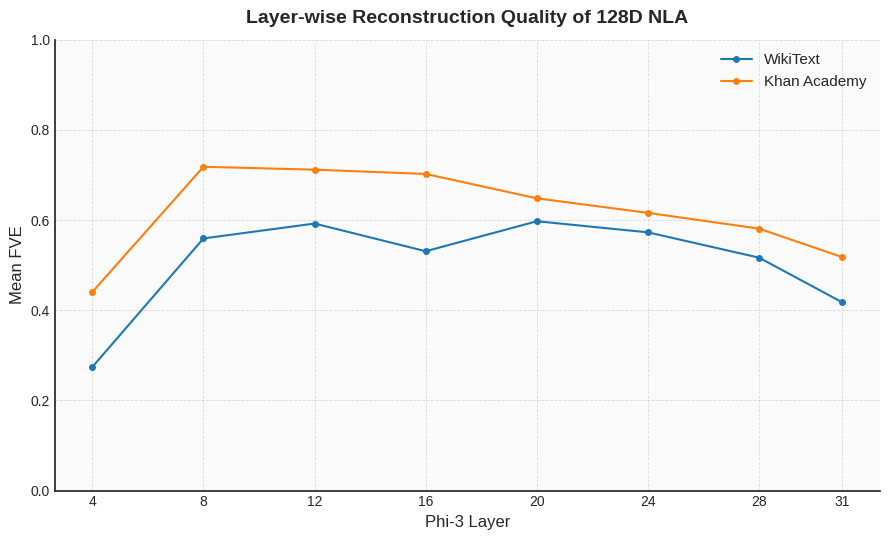

In [4]:
import matplotlib.pyplot as plt

layers = [4, 8, 12, 16, 20, 24, 28, 31]

plt.style.use("seaborn-v0_8-white")

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.set_facecolor("#fafafa")

ax.plot(
    layers, wiki_results_df["mean_fve"],
    marker="o", markersize=4,
    linewidth=1.5, label="WikiText"
)

ax.plot(
    layers, khanacademy_results_df["mean_fve"],
    marker="o", markersize=4,
    linewidth=1.5, label="Khan Academy"
)

ax.set_xticks(layers)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax.set_xlabel("Phi-3 Layer", fontsize=12)
ax.set_ylabel("Mean FVE", fontsize=12)

ax.set_ylim(0, 1)


ax.set_title(
    "Layer-wise Reconstruction Quality of 128D NLA", fontsize=14,
    fontweight="bold", pad=12
)

ax.grid(
    True, linestyle="--",
    linewidth=0.6, alpha=0.7
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q9. What do the layer-wise FVE curves reveal?

To understand how semantic recoverability varies with depth, I plotted the Fraction of Variance Explained (FVE) values against the layer number for both WikiText and Khan Academy datasets. The curves show a few clear trends.

### **Observation 1:** Early layers have low semantic recoverability
In both datasets, the lowest reconstruction quality is at the earliest layer we analyzed (Layer 4). For example, WikiText shows an FVE of 0.274 and Khan Academy is at 0.440. This suggests that early transformer layers mostly handle lexical and syntactic information or local context, which doesn't compress well into high-level semantic concepts.

### **Observation 2:** Semantic structure emerges in the intermediate layers
As we go deeper, the reconstruction quality improves significantly. For WikiText, the FVE rises from 0.274 at Layer 4 to about 0.60 in the middle layers. Khan Academy improves even faster, crossing 0.70 by Layer 8. This confirms the general idea that semantic abstractions emerge as information moves through the network, making these intermediate layers very compatible with semantic compression.

### **Observation 3:** WikiText and Khan Academy show different behaviors
While both datasets improve in the middle, their curves are quite different. WikiText peaks around Layer 20 and then starts to decline. In contrast, Khan Academy reaches high quality much earlier and stays there, forming a broad plateau from Layer 8 to 16 rather than a sharp peak. It seems educational content creates representations that are consistently easier to compress across a larger section of the network.

### **Observation 4:** Recoverability drops off near the output layers
Both datasets show a gradual decline in FVE in the deepest layers. For instance, WikiText drops from 0.610 at Layer 20 to 0.437 at Layer 31, and Khan Academy drops from 0.718 at Layer 8 to 0.518 at Layer 31. This is likely because the final layers become specialized for next-token prediction, containing information that is useful for the specific output but harder to recover through a semantic bottleneck.

### **Observation 5:** Educational content is consistently more recoverable
A key observation is that the Khan Academy curve stays above the WikiText curve at every layer. This indicates that educational text is consistently easier to recover. This might be because educational content is highly structured and concept-heavy, whereas WikiText has more entity-specific facts that are harder to summarize into a compact representation.

### **Key Takeaway**
The FVE curves show that semantic recoverability isn't uniform across the model. Semantic information emerges gradually, peaks in the intermediate layers, and then declines near the output. The specific shape also depends on the dataset; educational content shows a stable plateau of high recoverability, while encyclopedic text like WikiText is more sensitive to the choice of layer.

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q10. Why does Khan Academy achieve substantially higher FVE than WikiText?

One of the most surprising findings of this project was the large performance gap between the two datasets.

Across all analyzed layers, Khan Academy consistently achieved higher FVE values than WikiText.

Examples include:

| Layer | WikiText FVE | Khan Academy FVE |
| ----- | -----------: | ---------------: |
| 4     |        0.274 |            0.440 |
| 8     |        0.559 |            0.718 |
| 12    |        0.592 |            0.711 |
| 20    |        0.597 |            0.648 |
| 31    |        0.417 |            0.517 |

The difference isn't limited to just one layer. We see the Khan Academy curve staying above the WikiText curve across the entire transformer hierarchy. This suggests that semantic recoverability depends as much on the nature of the text as it does on the model architecture.


### Hypothesis 1: Educational content is inherently concept-centric

Khan Academy lessons are primarily designed to explain concepts.

Examples include:

* Scientific principles
* Mathematical ideas
* Definitions
* Intuitions
* Step-by-step reasoning

As a result, much of the information contained in the activations can be summarized using a relatively small number of semantic concepts.

This makes the content naturally compatible with a semantic bottleneck.

### Hypothesis 2: WikiText contains more entity-specific information

In contrast, WikiText contains a large amount of encyclopedic content involving:

* People
* Locations
* Historical events
* Organizations
* Dates
* Proper nouns

These details are often important for reconstructing the original activations but may be difficult to preserve through a compact semantic representation.

As a result, some information may be lost during compression even when the overall topic is retained.

### Hypothesis 3: Richer semantic descriptions improve supervision quality

For the Khan Academy experiments, a larger context window was used during description generation.

```python
max_length = 4096
```

This allowed Phi-3 to process much longer passages before generating semantic descriptions.

Manual inspection of the generated descriptions revealed that they were often richer and more representative of the underlying content.

Because these descriptions are converted into MiniLM embeddings and used as semantic supervision targets, higher-quality descriptions likely provide stronger semantic guidance during training.

### Hypothesis 4: Educational content aligns naturally with embedding-based supervision

The semantic supervision used in this project is based on MiniLM embeddings derived from generated descriptions.

Educational text tends to express concepts explicitly and consistently, making it easier for embedding models to capture the underlying meaning.

This may allow the semantic bottleneck to preserve a larger fraction of the activation structure compared to encyclopedic text, where important information is often tied to specific entities and factual details.

### Key Takeaway

The results suggest that semantic recoverability is strongly influenced by the type of content being processed.

Educational text appears to be significantly easier to compress and reconstruct through a semantic bottleneck than encyclopedic text.

This finding indicates that the effectiveness of Natural Language Autoencoders may depend not only on model architecture and training procedures, but also on the semantic characteristics of the underlying data.

The observation that Khan Academy reaches FVE values above 0.70 while WikiText peaks around 0.61 was one of the most unexpected and interesting outcomes of the project.


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q11. What do the latent bottlenecks reveal?

Reconstruction quality shows how well activations are recovered, but it's just as important to look at how the 128-dimensional bottleneck is being utilized. A common issue here is latent collapse, where only a small subset of dimensions actually stay active while others contribute almost nothing. To check if this was happening, I tracked the latent activation statistics across all experiments.


### Observation 1: The bottleneck remains highly utilized

Across both WikiText and Khan Academy experiments, nearly all latent dimensions remained active throughout training.

Examples include:

| Layer | WikiText Active Dimensions | Khan Academy Active Dimensions |
| ----- | -------------------------: | -----------------------------: |
| 4     |                        122 |                            127 |
| 8     |                        128 |                            128 |
| 12    |                        128 |                            128 |
| 16    |                        127 |                            128 |
| 20    |                        128 |                            128 |
| 24    |                        128 |                            128 |
| 28    |                        128 |                            128 |
| 31    |                        128 |                            128 |

This indicates that the bottleneck did not collapse and that information was distributed across most of the available latent space.

### Observation 2: Latent activation spread increases with depth

For both datasets, the latent standard deviation generally increases in deeper transformer layers. Refer the `Tables` sub-section in the same notebook which is after Q7.

For example:

* WikiText: 0.17 (Layer 4) → 0.75 (Layer 31)
* Khan Academy: 0.17 (Layer 4) → 0.74 (Layer 31)

Similarly, the maximum and minimum latent values become larger in magnitude in later layers.

This suggests that deeper transformer representations require a broader latent activation range to preserve important information during compression.

### Interpretation

The latent statistics show that the bottleneck is being used effectively throughout the training process. Instead of just relying on a few dominant features, the model develops a distributed representation that uses almost all the available dimensions. Also, the increasing latent spread in the deeper layers aligns with the hypothesis that later transformer layers contain more specialized representations, which seem to need stronger activations for reconstruction.

### Key Takeaway

The 128-dimensional bottleneck successfully compresses 3072-dimensional transformer activations without exhibiting latent collapse.

Across both datasets and all analyzed layers, the latent space remained highly utilized, indicating that meaningful compression was achieved while preserving enough information for both semantic supervision and activation reconstruction.


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Code: Best and Worst Samples

In [5]:
import os
import json
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split

BASE_DIR = "/content/drive/MyDrive/Natural Language Autoencoder"

LAYERS = [4, 8, 12, 16, 20, 24, 28, 31]

SEED = 42

def create_best_worst_df(dataset_name):

    # Load Dataset

    with open(os.path.join(BASE_DIR, "data", dataset_name, "dataset.json"), "r") as f:
        dataset = json.load(f)

    # Recreate Train/Test Split

    indices = np.arange(len(dataset))

    train_idx, test_idx = train_test_split(indices, test_size=0.1, random_state=SEED, shuffle=True)

    rows = []
    # Process Each Layer

    for layer in LAYERS:

        scores = torch.load(
            os.path.join(BASE_DIR, "results", dataset_name, f"Layer_{layer}", "fve_scores.pt"))

        best_test_idx = scores.argmax().item()
        worst_test_idx = scores.argmin().item()

        best_idx = test_idx[best_test_idx]
        worst_idx = test_idx[worst_test_idx]

        rows.append({

            "Layer": layer,

            "Best Index": int(best_idx),
            "Best FVE": float(scores[best_test_idx]),
            "Best Description":
                dataset[best_idx]["phi3_description"],

            "Worst Index": int(worst_idx),
            "Worst FVE": float(scores[worst_test_idx]),
            "Worst Description":
                dataset[worst_idx]["phi3_description"]
        })

    return pd.DataFrame(rows)


# =====================================================
# Create DataFrames
# =====================================================

wiki_best_worst_df = create_best_worst_df("wikitext").set_index("Layer")

khanacademy_best_worst_df = create_best_worst_df("khanacademy").set_index("Layer")

In [ ]:
print("WikiText")
display(wiki_best_worst_df)

WikiText


,Best Index,Best FVE,Best Description,Worst Index,Worst FVE,Worst Description
Layer,,,,,,
4,1144,0.915390,"Japanese invasion threat, Torres Strait defens...",3970,-0.976426,Oldham war memorial First World War soldiers
8,1144,0.876929,"Japanese invasion threat, Torres Strait defens...",1941,0.101332,Evita Perón funeral chaos
12,1144,0.944646,"Japanese invasion threat, Torres Strait defens...",4118,0.165293,Irish whiskey market decline
16,1144,0.930960,"Japanese invasion threat, Torres Strait defens...",1433,0.064472,British illustrator Flower Fairies
20,1144,0.885832,"Japanese invasion threat, Torres Strait defens...",4315,0.371939,Nixon's inaugural address and foreign policy i...
24,1144,0.919358,"Japanese invasion threat, Torres Strait defens...",505,0.270845,Central Pacific naming convention
28,3654,0.935952,Federer's Wimbledon defeat and ranking drop,333,0.138265,Lighthouse as artistic inspiration and swim race
31,3654,0.911643,Federer's Wimbledon defeat and ranking drop,333,0.103300,Lighthouse as artistic inspiration and swim race


In [ ]:
print("\nKhan Academy")
display(khanacademy_best_worst_df)


Khan Academy


,Best Index,Best FVE,Best Description,Worst Index,Worst FVE,Worst Description
Layer,,,,,,
4,3773,0.906618,Inequality Plotting,3630,-0.552041,Integration by Parts Application in Physics
8,2280,0.930787,Federal Bureaucracy in American Government,4520,0.305620,Bacterial growth exponential models real-world...
12,3557,0.917732,Adding fractions with denominators 10 and 100,1588,0.348804,Mathematical Patterns on Coordinate Plane
16,3557,0.911316,Adding fractions with denominators 10 and 100,109,0.411103,Pythagorean theorem application in related rat...
20,1292,0.868504,Chemical kinetics temperature dependence,3821,0.362506,Rectangle properties on coordinate plane
24,3591,0.832863,58,240,0.169539,Even and Odd Functions: Common Errors in Graph...
28,1872,0.829522,Adding Fractions with Like Denominators,240,0.138138,Even and Odd Functions: Common Errors in Graph...
31,252,0.770888,Linear Equations System Solving,240,0.079318,Even and Odd Functions: Common Errors in Graph...


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q12. What were the most interesting qualitative findings?

While aggregate metrics such as FVE and cosine similarity provide an overall measure of reconstruction quality, they do not reveal which types of content are easiest or most difficult to compress through a semantic bottleneck.

To better understand the behavior of the model, the highest- and lowest-performing samples were examined across multiple layers and datasets.

### Observation 1: Samples with a single dominant concept are reconstructed most effectively

Many of the highest-FVE samples revolve around a clearly defined central idea.

Examples include:

**WikiText**

* Japanese invasion threat and Torres Strait defense
* Federer's Wimbledon defeat and ranking drop

**Khan Academy**

* Inequality Plotting
* Adding Fractions with Denominators 10 and 100
* Chemical Kinetics Temperature Dependence
* Linear Equations System Solving

These topics can be summarized by a relatively compact semantic description without losing much of their essential meaning. As a result, the bottleneck is able to preserve a large fraction of the information required for reconstruction.

Several of these samples achieved FVE values above 0.90, indicating that substantial activation structure survives semantic compression.

### Observation 2: Multi-concept and relationship-heavy topics are more difficult to reconstruct

Many of the lower-performing samples involve multiple interacting ideas, relationships, or contextual details.

Examples include:

**WikiText**

* Jordan's divorce settlement details
* Voice actors uncredited
* Lighthouse as artistic inspiration and swim race

**Khan Academy**

* Integration by Parts Application in Physics
* Mathematical Patterns on Coordinate Plane
* Pythagorean Theorem Application in Related Rates
* Even and Odd Functions: Common Errors in Graph Interpretation

Unlike the best-performing examples, these topics often require preserving relationships between multiple concepts rather than a single dominant theme.

A short semantic description may capture the general subject matter while omitting important details, resulting in lower reconstruction quality.

### Observation 3: Strong reconstructions are remarkably consistent across layers

An interesting pattern emerged when comparing the best samples across transformer layers.

For WikiText, topics such as:

* Japanese invasion threat and Torres Strait defense
* Federer's Wimbledon defeat and ranking drop

appeared repeatedly among the strongest reconstructions.

Similarly, for Khan Academy, topics such as:

* Adding Fractions
* Linear Equations
* Inequality Plotting

consistently achieved high reconstruction quality.

This suggests that certain concepts generate representations that remain highly recoverable throughout multiple stages of the transformer hierarchy.

### Observation 4: Poor reconstruction does not necessarily imply failure

Although some samples achieved substantially lower FVE than others, many of the lowest-performing examples in the final experiments still retained positive FVE values.

This is an important distinction from earlier experimental runs, where negative FVE values were more common.

The final jointly-trained architecture appears significantly more robust, preserving a meaningful fraction of activation variance even for difficult samples.

### Interpretation

Taken together, these observations suggest that semantic bottlenecks are most effective when the underlying content can be represented by a single dominant semantic idea.

As the number of interacting concepts, contextual dependencies, or relationships increases, the compression task becomes more challenging because a short semantic representation may not fully capture all relevant information.

This behavior is consistent with the central intuition behind Natural Language Autoencoders: semantic compression works best when meaning can be expressed compactly and becomes increasingly difficult when important information is distributed across multiple concepts or relationships.

### Key Takeaway

The qualitative analysis indicates that reconstruction quality depends not only on transformer depth but also on the semantic structure of the underlying content.

Samples organized around a single dominant concept are reconstructed most effectively, while relationship-heavy and multi-concept content presents a greater challenge for semantic compression.


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q13. How close did we get to Anthropic's Natural Language Autoencoder?

The goal here wasn't to exactly replicate Anthropic's Natural Language Autoencoder. Instead, I wanted to see if similar behaviors would emerge using a smaller open-source model and a more feasible training setup.

Anthropic reports Fraction of Variance Explained (FVE) values in the range of approximately 0.6–0.8 on Claude models.

The best results obtained in this project were:

| Dataset      | Best Layer | Mean FVE |
| ------------ | ---------: | -------: |
| WikiText     |   Layer 20 |    0.597 |
| Khan Academy |    Layer 8 |    0.718 |

These results indicate that the simplified implementation is capable of approaching, and in some cases entering, the range reported in the Anthropic work.

### Important Differences from Anthropic's Implementation

Despite the encouraging reconstruction performance, several significant differences exist between the two systems.

Anthropic's NLA includes:

* Large proprietary Claude models
* Sparse Autoencoders (SAEs)
* Reinforcement-learning-based optimization components
* Large-scale training infrastructure
* Significantly larger datasets

In contrast, this project uses:

* Phi-3-mini
* A dense 128-dimensional bottleneck
* Joint reconstruction and semantic supervision
* Approximately 5,000 samples per dataset
* Colab-scale experimentation

**Therefore, this work is intended as a simplified replication rather than a direct reproduction.**

### **Why Do the Results Differ?**

Several factors likely contribute to the gap between this implementation and Anthropic's full system.

1. Using a smaller open-source model limits the representational capacity available at the activation bottleneck.
2. I didn't explore Sparse Autoencoders in this study. Anthropic's research shows that using sparse representations can lead to much more interpretable and specialized features, but that was beyond the current scope.
3. The scale of training data and compute power I have for this project is much smaller than what is typically available in industrial research labs.
4.The semantic supervision here uses MiniLM embeddings from the generated descriptions, rather than the more complex optimization methods mentioned in the Anthropic paper.

### What Was Successfully Replicated?

Despite these simplifications, several core behaviors reported by Anthropic were successfully reproduced.

These include:

* Non-trivial activation reconstruction through a semantic bottleneck
* Strong semantic recoverability in intermediate transformer layers
* Meaningful variation in recoverability across transformer depth
* High reconstruction quality for concept-focused content
* FVE values approaching the range reported in the original work

The most important finding here is that much of the transformer activation structure actually survives aggressive semantic compression and we can still reconstruct it with high fidelity.

### Key Takeaway

Although this project does not reproduce the full Anthropic NLA system, it successfully captures the central idea behind the approach: **transformer activations contain semantic structure that can be compressed, supervised through language-derived representations, and reconstructed with surprisingly high fidelity.**

The strongest configuration achieved an FVE of 0.718, demonstrating that even a simplified implementation can recover a large fraction of the original activation variance while operating under significantly smaller computational constraints.


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

# Q14. What are the limitations of this study?

While the results obtained in this project are encouraging, several limitations should be acknowledged.

### Limitation 1: Dense bottlenecks were used instead of Sparse Autoencoders

The main difference from Anthropic's implementation is that I used a dense 128-dimensional bottleneck.

Their work relies on Sparse Autoencoders (SAEs) to get more interpretable features through specialization. Because of limited time and compute resources, I didn't explore sparse bottlenecks in this study, so these latent representations likely aren't as interpretable as the ones they reported.

### Limitation 2: Single-layer activations were analyzed independently

For each experiment, I used activations from a single transformer layer. While this approach allows for direct comparisons between layers, it doesn't really account for the interactions between them.

It would be worth exploring if combining information from multiple layers improves semantic recovery and reconstruction quality.

### Limitation 3: Semantic supervision depends on generated descriptions

For training, we derive the semantic targets from Phi-3 generated descriptions and MiniLM embeddings. While this approach offers a practical way to handle semantic supervision, the results are tied to the quality of the descriptions themselves.

Any errors, omissions, or simplifications in these descriptions will likely affect the learned bottleneck representations.

### Limitation 4: Dataset scale remains modest

The largest experiments in this project used approximately 5,000 samples per dataset.

While sufficient for studying trends and validating the overall approach, this scale is substantially smaller than the datasets typically used in large-scale interpretability research.

Additional data may further improve reconstruction quality and reveal more robust patterns.

### Limitation 5: Computational constraints limited exploration

I've not explored several directions like Sparse Autoencoders, Multi-layer bottlenecks, alternative semantic embedding models etc.. The reason is due to time and compute limitations.

As a result, the findings presented here should be viewed as an initial investigation rather than a comprehensive exploration of Natural Language Autoencoders.

### Key Takeaway

The experiments successfully demonstrate that semantic bottlenecks can reconstruct transformer activations with high fidelity under practical computational constraints.

However, the current implementation represents only a subset of the design space explored in the Anthropic work, leaving several promising directions for future investigation.


⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹

⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹⏹